# Chapter 7: Multivariate descriptive

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

## 7.1 Introduction & Problem Setting

We have seen how we can evaluate individual columns in a dataset, but now it is time to look at the bigger picture and discover how all the data is related! To do so, we will be working with a dataset of wine qualities. We will be working on two datasets: one of white wine and one of red wine. You will be merging them into a single dataset and exploring the differences.

## 7.2 Data Loading & Initial Exploration

Import both datasets. Explore them like we did before (content, size, ...) and merge them into a single dataset. Make sure to add a variable called 'Colour' to indicate the color wine (aka. from which dataset of the two your datapoint originates)!

Do you notice anything interesting between both datasets?

In [8]:
whine_white = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Multivariate Descriptive/winequality-white.csv",sep=";")
whine_red = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Multivariate Descriptive/winequality-red.csv",sep=";")

In [10]:
whine_white["color"] = "White"
whine_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,White
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,White
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,White
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White


In [11]:
whine_red["color"] = "Red"
whine_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red


In [56]:
wine = pd.concat([whine_white,whine_red],ignore_index=True)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,White
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,White
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,White
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,White


## 7.3 Multivariate descriptive

Do some research by exploring the dataset with the methods we have seen up till now. Is there a relation between the alcohol level and the colour of a given wine? Elaborate on your conclusion.

*Hint: calculate the mean and std per colour, and then plot a histogram to compare.*

In [74]:
wine_mean = wine.groupby("color").mean()
wine_mean

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
color,,,,,,,,,,,,
Red,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
White,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909


In [75]:
wine_std = wine.groupby("color").std()
wine_std

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
color,,,,,,,,,,,,
Red,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
White,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639


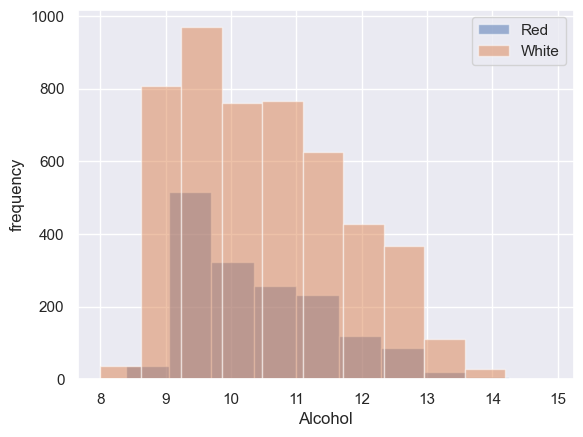

In [77]:
plt.hist(wine[wine["color"]=="Red"]["alcohol"],alpha=0.5,label="Red")
plt.hist(wine[wine["color"]=="White"]["alcohol"],alpha=0.5,label="White")
plt.xlabel("Alcohol")
plt.ylabel("frequency")
plt.legend()
plt.show()

## 7.4: Correlations

Which variables have the highest correlations? Is this to be expected? Elaborate by doing the following things:

- Calucate the correlation matrix. Print it and explore.
- Visualize the correlation matrix in a heatmap. Which correlations can you find? Are they positive or negative? Are they logical?

In [82]:
corrMattrix=wine.drop(columns="color").corr()
corrMattrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


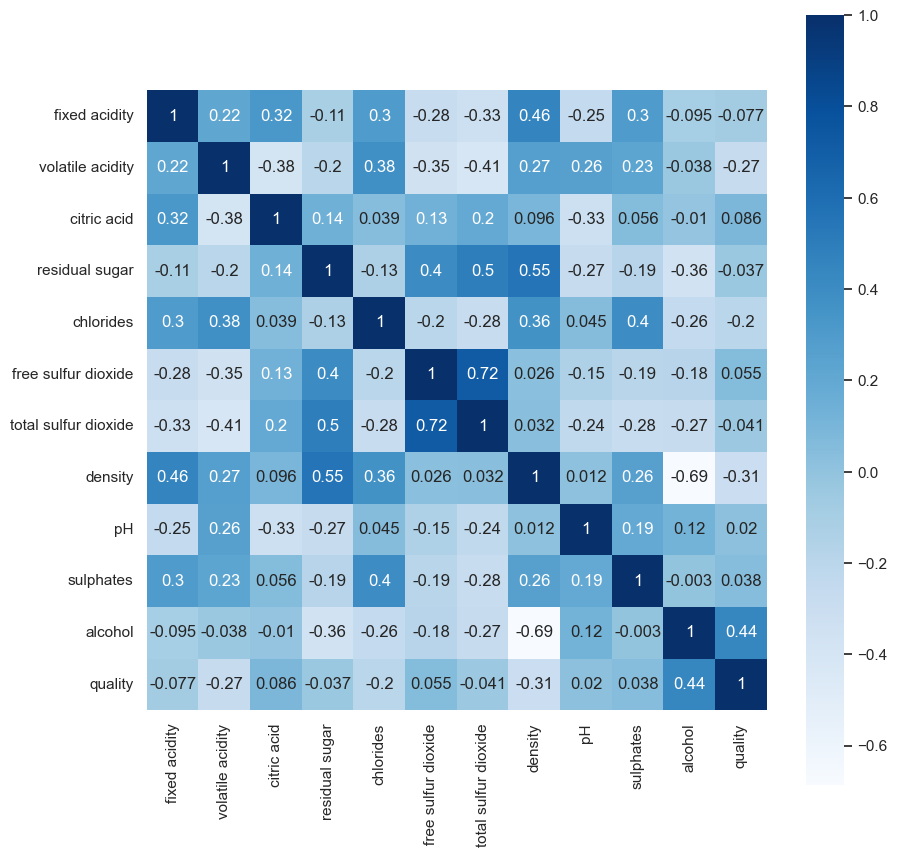

In [84]:
fig=plt.figure(figsize=(10,10))
fig=sns.heatmap(corrMattrix,annot=True,square=True,cmap="Blues")
plt.show()

A mixture of positive and negative correlation...where alcohol vs quality has the strongest relation with 0.44